In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
!pip install fpdf

from fpdf import FPDF

# 2. Create a list of 50 student IDs
student_ids = [f'Student_{i+1}' for i in range(50)]

# 3. Define a list of 5 subject names
subjects = ['Math', 'Science', 'History', 'Art', 'English']

# 4. Initialize an empty dictionary to store the data for the DataFrame
data = {}

# 5. For each subject, generate 50 random numerical grades (e.g., between 50 and 100)
# 6. Randomly replace a certain percentage (e.g., 10-20%) of grades in each subject column with np.nan
np.random.seed(42) # for reproducibility

for subject in subjects:
    grades = np.random.randint(50, 101, size=50).astype(float) # Ensure float type for NaN
    # Introduce NaNs: replace 10-20% of grades with NaN
    num_nan = np.random.randint(5, 11) # between 5 and 10 NaNs for 50 entries (10-20%)
    nan_indices = np.random.choice(50, num_nan, replace=False)
    grades[nan_indices] = np.nan
    data[subject] = grades

# 7. Create a pandas DataFrame df from the generated data, using the student IDs as the index and subject names as columns
df = pd.DataFrame(data, index=student_ids)

# 8. Display the first few rows of the created df DataFrame using .head() to verify its structure and content.
print("Generated DataFrame head:")
df.head()

Generated DataFrame head:


,Math,Science,History,Art,English
Student_1,88.0,100.0,98.0,51.0,94.0
Student_2,78.0,66.0,61.0,84.0,NaN
Student_3,NaN,57.0,88.0,65.0,50.0
Student_4,92.0,NaN,51.0,NaN,57.0
Student_5,57.0,84.0,52.0,NaN,95.0


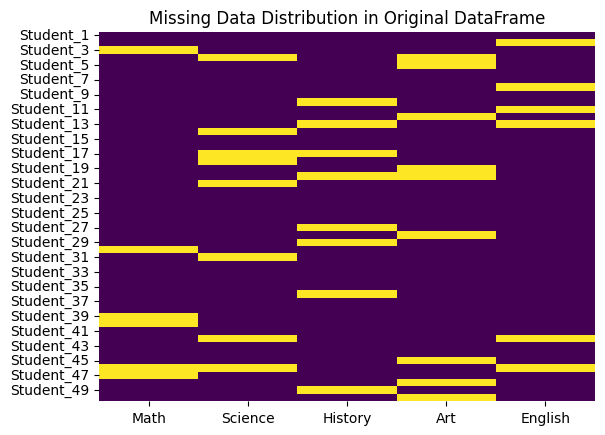

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of the null values in the df DataFrame
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Distribution in Original DataFrame')
plt.show()

In [41]:
df_mean_imputed = df.copy()

subjects = ['Math', 'Science', 'History', 'Art', 'English']

for subject in subjects:
    df_mean_imputed[subject].fillna(df_mean_imputed[subject].mean(), inplace=True)

print("df_mean_imputed head after mean imputation:")
print(df_mean_imputed.head())

print("\ndf_mean_imputed info after mean imputation:")
df_mean_imputed.info()

df_mean_imputed head after mean imputation:
                Math    Science  History        Art    English
Student_1  88.000000  100.00000     98.0  51.000000  94.000000
Student_2  78.000000   66.00000     61.0  84.000000  76.795455
Student_3  75.704545   57.00000     88.0  65.000000  50.000000
Student_4  92.000000   74.47619     51.0  76.121951  57.000000
Student_5  57.000000   84.00000     52.0  76.121951  95.000000

df_mean_imputed info after mean imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


/tmp/ipykernel_563/1008209477.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean_imputed[subject].fillna(df_mean_imputed[subject].mean(), inplace=True)


In [42]:
df_mean_imputed = df.copy()

subjects = ['Math', 'Science', 'History', 'Art', 'English']

for subject in subjects:
    df_mean_imputed[subject] = df_mean_imputed[subject].fillna(df_mean_imputed[subject].mean())

print("df_mean_imputed head after mean imputation:")
print(df_mean_imputed.head())

print("\ndf_mean_imputed info after mean imputation:")
df_mean_imputed.info()

df_mean_imputed head after mean imputation:
                Math    Science  History        Art    English
Student_1  88.000000  100.00000     98.0  51.000000  94.000000
Student_2  78.000000   66.00000     61.0  84.000000  76.795455
Student_3  75.704545   57.00000     88.0  65.000000  50.000000
Student_4  92.000000   74.47619     51.0  76.121951  57.000000
Student_5  57.000000   84.00000     52.0  76.121951  95.000000

df_mean_imputed info after mean imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


In [43]:
df_median_imputed = df.copy()

subjects = ['Math', 'Science', 'History', 'Art', 'English']

for subject in subjects:
    df_median_imputed[subject] = df_median_imputed[subject].fillna(df_median_imputed[subject].median())

print("df_median_imputed head after median imputation:")
print(df_median_imputed.head())

print("\ndf_median_imputed info after median imputation:")
df_median_imputed.info()

df_median_imputed head after median imputation:
           Math  Science  History   Art  English
Student_1  88.0    100.0     98.0  51.0     94.0
Student_2  78.0     66.0     61.0  84.0     77.0
Student_3  73.5     57.0     88.0  65.0     50.0
Student_4  92.0     76.0     51.0  78.0     57.0
Student_5  57.0     84.0     52.0  78.0     95.0

df_median_imputed info after median imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


In [44]:
from sklearn.linear_model import LinearRegression

df_regression_imputed = df.copy()

subjects = ['Math', 'Science', 'History', 'Art', 'English']

for subject_to_impute in subjects:
    predictor_cols = [col for col in subjects if col != subject_to_impute]

    # Create a temporary DataFrame to handle means for predictors
    df_temp = df_regression_imputed.copy()

    # Fill nulls in predictor columns with their respective means for this iteration
    # This is important for the training and prediction phases
    for col in predictor_cols:
        df_temp[col] = df_temp[col].fillna(df_regression_imputed[col].mean())

    # Identify rows where the subject_to_impute is not null for training
    train_mask = df_regression_imputed[subject_to_impute].notna()
    X_train = df_temp.loc[train_mask, predictor_cols]
    y_train = df_regression_imputed.loc[train_mask, subject_to_impute]

    # Identify rows where the subject_to_impute is null for prediction
    predict_mask = df_regression_imputed[subject_to_impute].isna()
    X_predict = df_temp.loc[predict_mask, predictor_cols]

    if not y_train.empty and not X_predict.empty:
        model = LinearRegression()
        model.fit(X_train, y_train)
        predicted_values = model.predict(X_predict)
        df_regression_imputed.loc[predict_mask, subject_to_impute] = predicted_values

print("df_regression_imputed head after regression imputation:")
print(df_regression_imputed.head())

print("\ndf_regression_imputed info after regression imputation:")
df_regression_imputed.info()

df_regression_imputed head after regression imputation:
                Math     Science  History        Art    English
Student_1  88.000000  100.000000     98.0  51.000000  94.000000
Student_2  78.000000   66.000000     61.0  84.000000  75.738718
Student_3  86.482589   57.000000     88.0  65.000000  50.000000
Student_4  92.000000   55.549794     51.0  80.564646  57.000000
Student_5  57.000000   84.000000     52.0  88.212068  95.000000

df_regression_imputed info after regression imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


In [45]:
df_ffill_imputed = df.copy()
df_ffill_imputed.fillna(method='ffill', inplace=True)

print("df_ffill_imputed head after forward-fill imputation:")
print(df_ffill_imputed.head())

print("\ndf_ffill_imputed info after forward-fill imputation:")
df_ffill_imputed.info()

df_ffill_imputed head after forward-fill imputation:
           Math  Science  History   Art  English
Student_1  88.0    100.0     98.0  51.0     94.0
Student_2  78.0     66.0     61.0  84.0     94.0
Student_3  78.0     57.0     88.0  65.0     50.0
Student_4  92.0     57.0     51.0  65.0     57.0
Student_5  57.0     84.0     52.0  65.0     95.0

df_ffill_imputed info after forward-fill imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


/tmp/ipykernel_563/1916642080.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill_imputed.fillna(method='ffill', inplace=True)


In [46]:
df_ffill_imputed = df.copy()
df_ffill_imputed = df_ffill_imputed.ffill()

print("df_ffill_imputed head after forward-fill imputation:")
print(df_ffill_imputed.head())

print("\ndf_ffill_imputed info after forward-fill imputation:")
df_ffill_imputed.info()

df_ffill_imputed head after forward-fill imputation:
           Math  Science  History   Art  English
Student_1  88.0    100.0     98.0  51.0     94.0
Student_2  78.0     66.0     61.0  84.0     94.0
Student_3  78.0     57.0     88.0  65.0     50.0
Student_4  92.0     57.0     51.0  65.0     57.0
Student_5  57.0     84.0     52.0  65.0     95.0

df_ffill_imputed info after forward-fill imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


**Reasoning**:
The subtask requires applying hot-deck imputation using the backward-fill method. This will replace null values with the next valid observation in the column. I will create a new DataFrame for this.



In [47]:
df_bfill_imputed = df.copy()
df_bfill_imputed = df_bfill_imputed.bfill()

print("df_bfill_imputed head after backward-fill imputation:")
print(df_bfill_imputed.head())

print("\ndf_bfill_imputed info after backward-fill imputation:")
df_bfill_imputed.info()

df_bfill_imputed head after backward-fill imputation:
           Math  Science  History   Art  English
Student_1  88.0    100.0     98.0  51.0     94.0
Student_2  78.0     66.0     61.0  84.0     50.0
Student_3  92.0     57.0     88.0  65.0     50.0
Student_4  92.0     84.0     51.0  82.0     57.0
Student_5  57.0     84.0     52.0  82.0     95.0

df_bfill_imputed info after backward-fill imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      49 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


In [48]:
df_bfill_imputed = df_bfill_imputed.ffill()

print("df_bfill_imputed head after second imputation (ffill to catch leading NaNs):")
print(df_bfill_imputed.head())

print("\ndf_bfill_imputed info after second imputation:")
df_bfill_imputed.info()

df_bfill_imputed head after second imputation (ffill to catch leading NaNs):
           Math  Science  History   Art  English
Student_1  88.0    100.0     98.0  51.0     94.0
Student_2  78.0     66.0     61.0  84.0     50.0
Student_3  92.0     57.0     88.0  65.0     50.0
Student_4  92.0     84.0     51.0  82.0     57.0
Student_5  57.0     84.0     52.0  82.0     95.0

df_bfill_imputed info after second imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Student_1 to Student_50
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Math     50 non-null     float64
 1   Science  50 non-null     float64
 2   History  50 non-null     float64
 3   Art      50 non-null     float64
 4   English  50 non-null     float64
dtypes: float64(5)
memory usage: 4.4+ KB


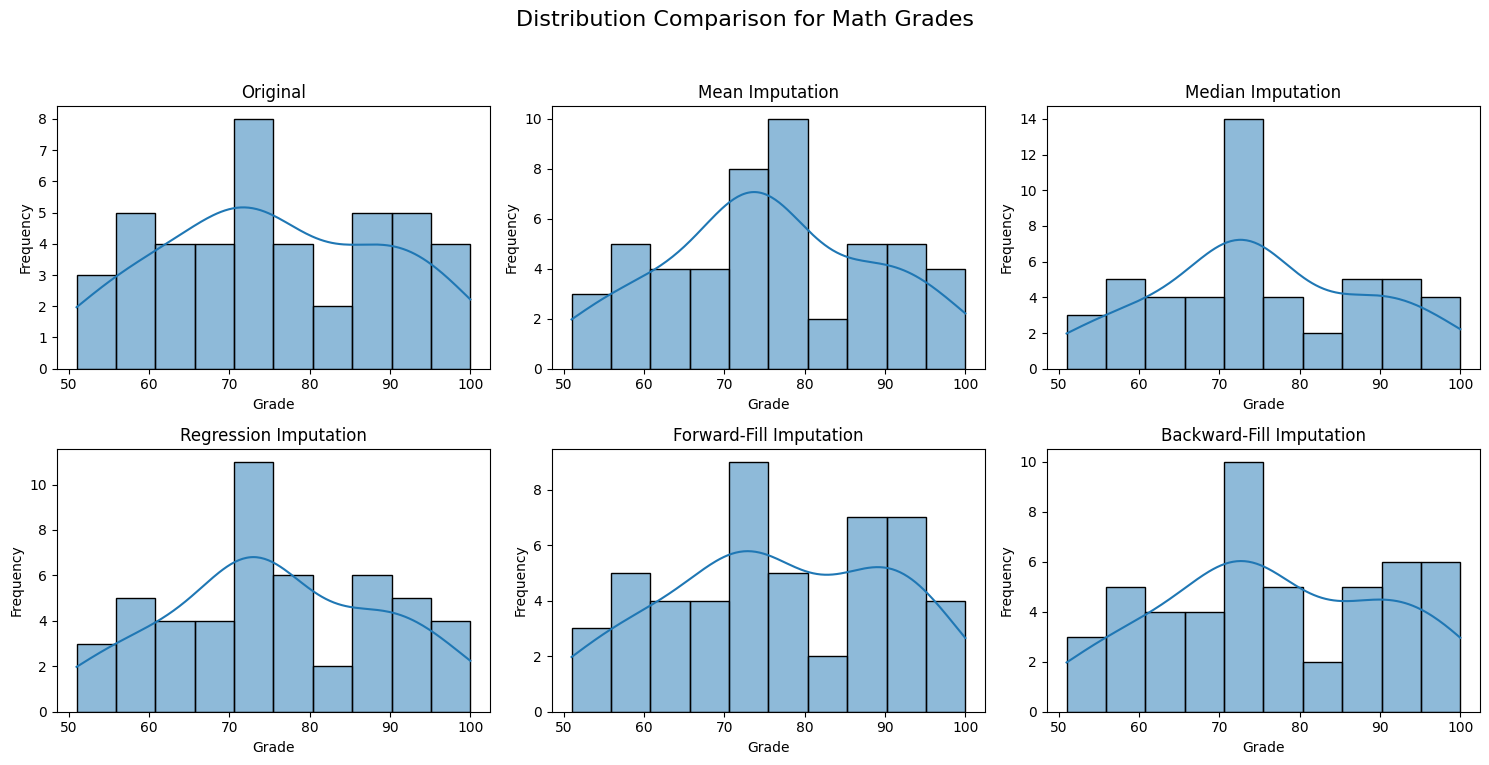

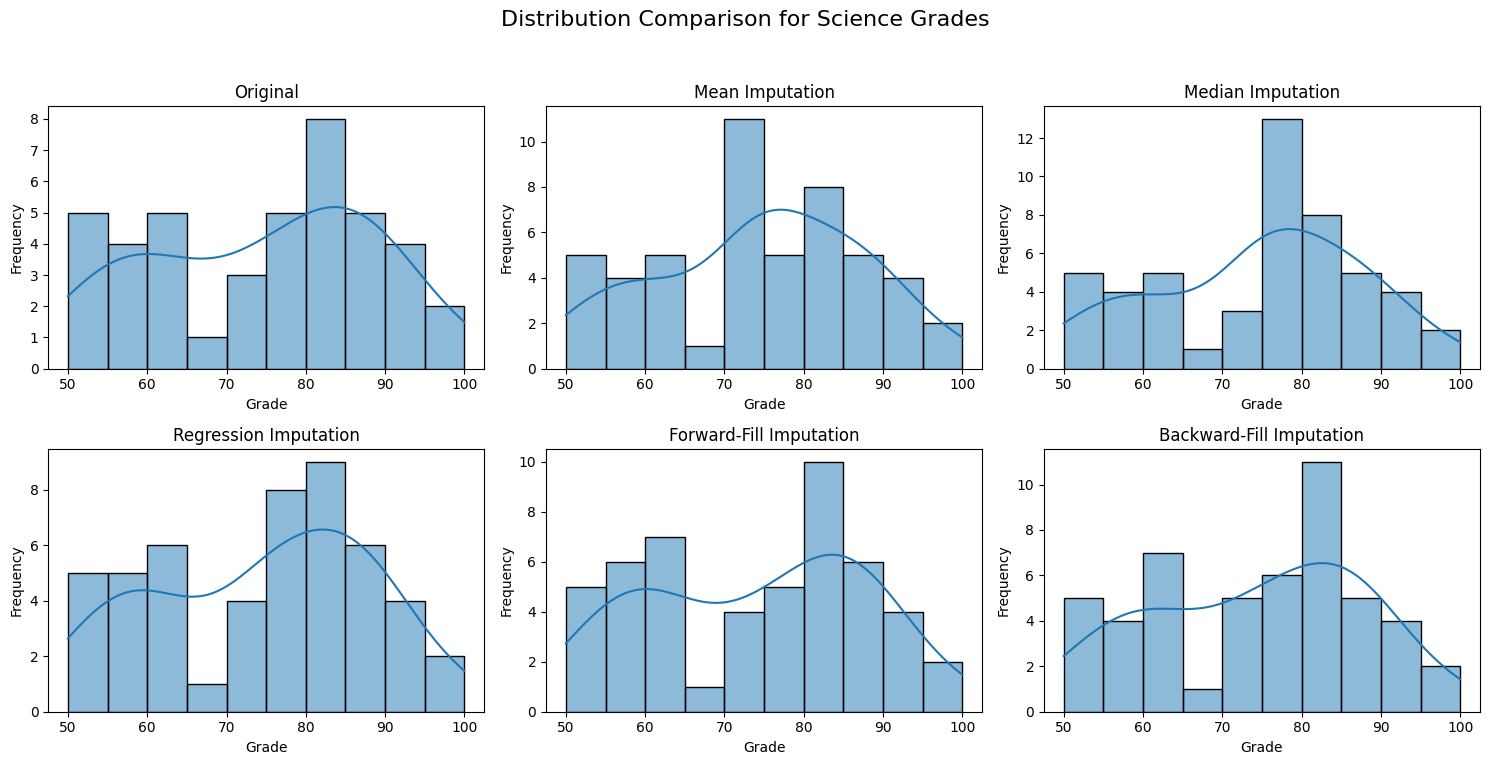

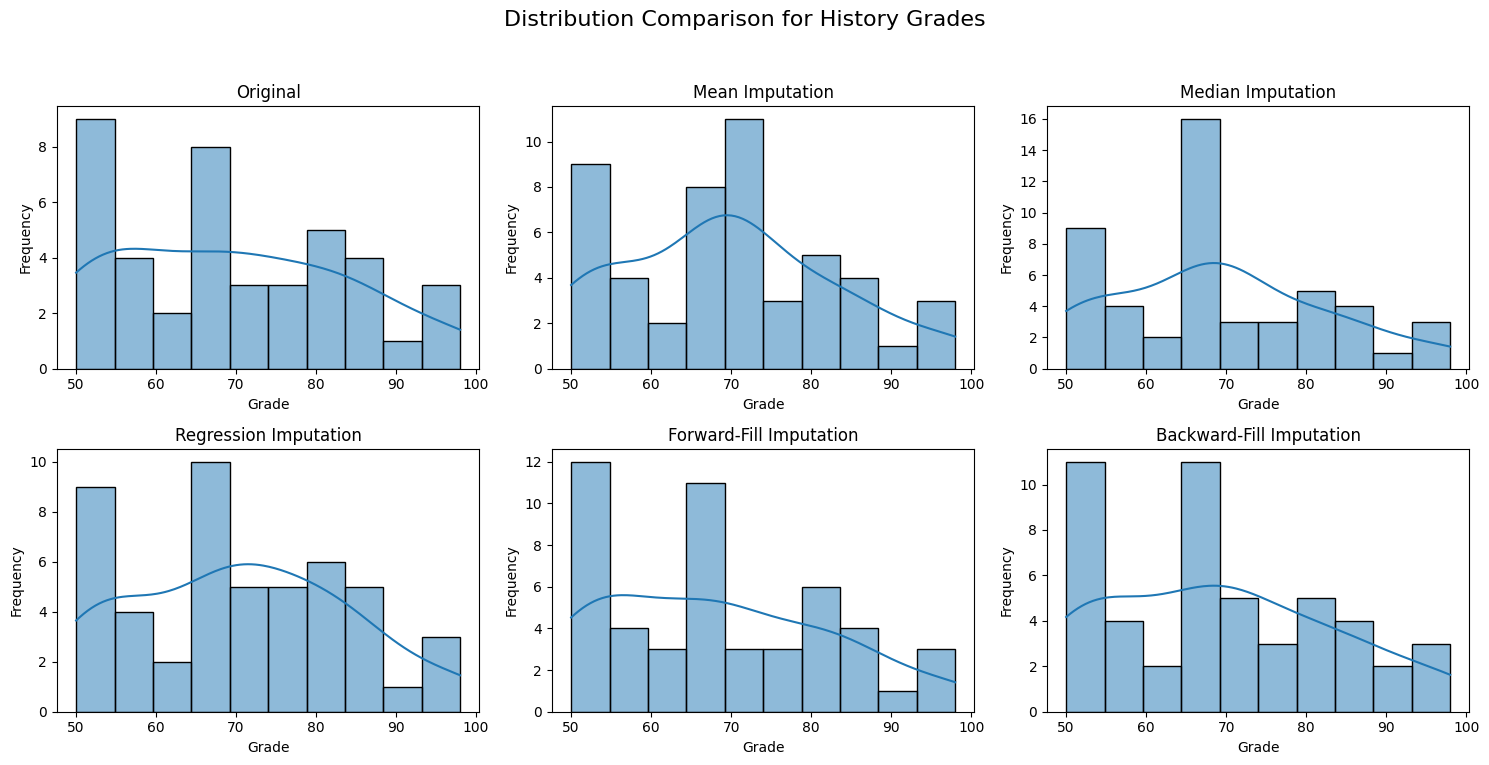

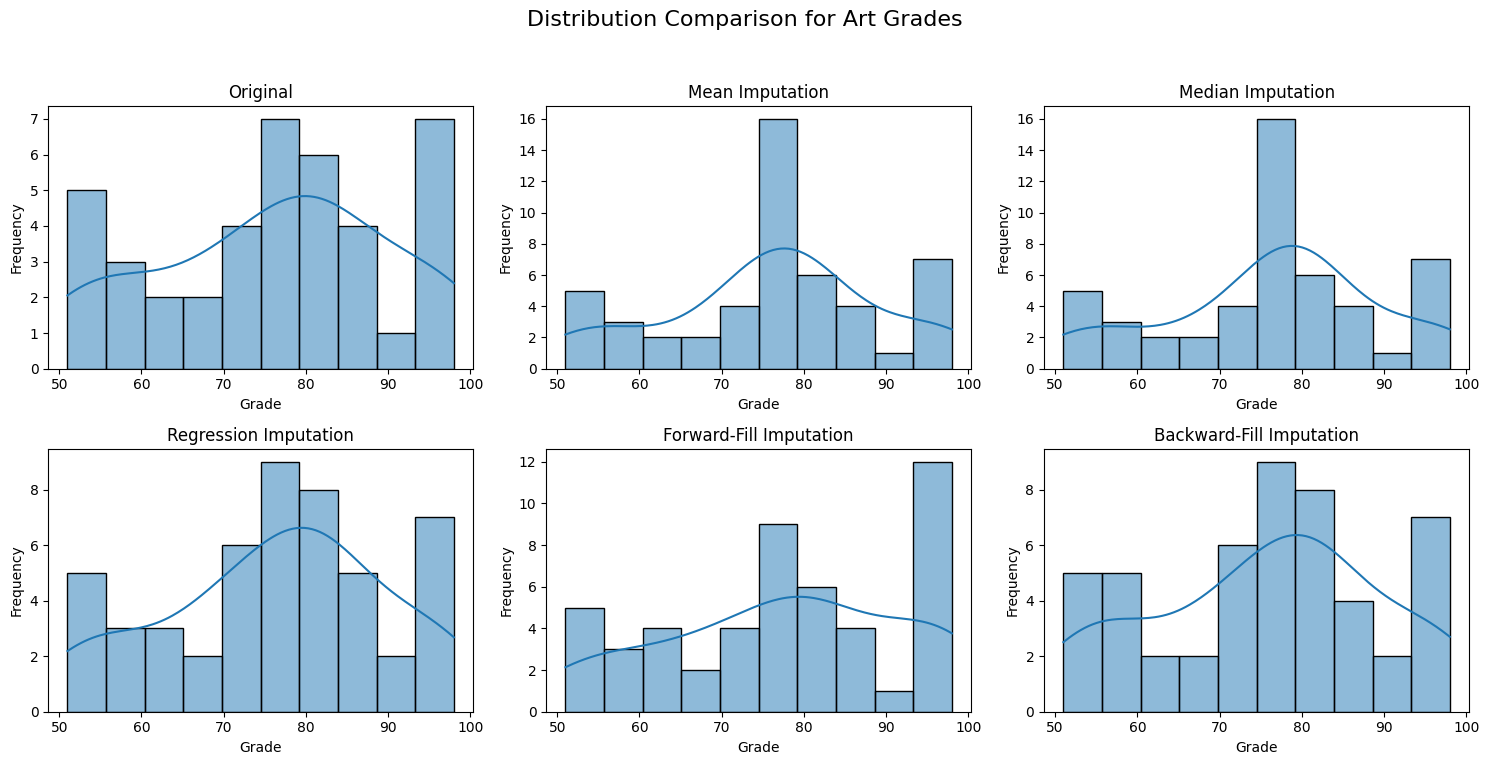

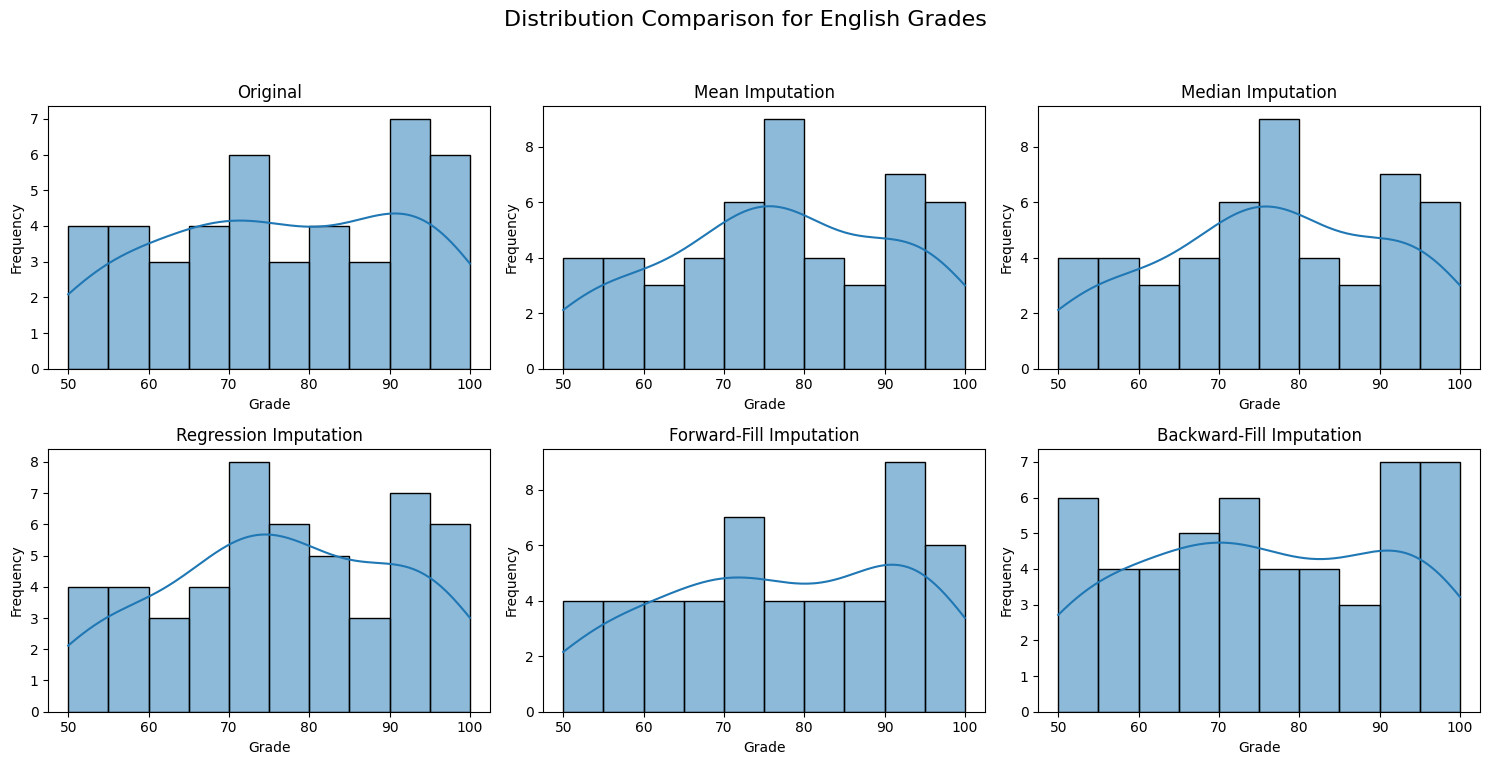

In [49]:
dataframes = {
    'Original': df,
    'Mean Imputation': df_mean_imputed,
    'Median Imputation': df_median_imputed,
    'Regression Imputation': df_regression_imputed,
    'Forward-Fill Imputation': df_ffill_imputed,
    'Backward-Fill Imputation': df_bfill_imputed
}

subjects = ['Math', 'Science', 'History', 'Art', 'English']

for subject in subjects:
    plt.figure(figsize=(15, 8))
    plt.suptitle(f'Distribution Comparison for {subject} Grades', fontsize=16)

    for i, (name, dataframe) in enumerate(dataframes.items()):
        plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
        sns.histplot(dataframe[subject], kde=True, bins=10)
        plt.title(name)
        plt.xlabel('Grade')
        plt.ylabel('Frequency')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [50]:
from fpdf import FPDF
import matplotlib.pyplot as plt
import os # To manage temporary files

class PDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, 'Missing Data Imputation Report', 0, 1, 'C')

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}/{{nb}}', 0, 0, 'C')

    def chapter_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.ln(10)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(5)

    def chapter_body(self, body):
        self.set_font('Arial', '', 10)
        self.multi_cell(0, 5, body)
        self.ln()

    def add_plot(self, plot_path, width=180):
        self.image(plot_path, x=self.get_x(), w=width)
        self.ln(5)

print("PDFReport class defined for generating the report.")

PDFReport class defined for generating the report.


In [51]:
pdf = PDFReport()
pdf.alias_nb_pages()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)

pdf.chapter_title('1. Introduction')
pdf.chapter_body("This report details a comprehensive analysis of missing data imputation techniques applied to a simulated student grades dataset. We compare mean, median, regression, and hot-deck (forward-fill and backward-fill) imputation methods, visualizing their impact on data distributions.")

# --- Add Initial Missing Data Visualization ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Distribution in Original DataFrame')
initial_null_plot_path = 'initial_null_distribution.png'
plt.savefig(initial_null_plot_path)
plt.close() # Close the plot to free memory

pdf.chapter_title('2. Initial Missing Data Visualization')
pdf.add_plot(initial_null_plot_path)
pdf.chapter_body("The heatmap above visually represents the distribution of missing values (in purple/yellow) across the subject columns in the original DataFrame. This provides a baseline understanding of the data sparsity before imputation.")

# --- Add Distribution Comparisons ---
dataframes = {
    'Original': df,
    'Mean Imputation': df_mean_imputed,
    'Median Imputation': df_median_imputed,
    'Regression Imputation': df_regression_imputed,
    'Forward-Fill Imputation': df_ffill_imputed,
    'Backward-Fill Imputation': df_bfill_imputed
}

subjects = ['Math', 'Science', 'History', 'Art', 'English']

pdf.chapter_title('3. Impact of Imputation Techniques on Data Distributions')
pdf.chapter_body("The following histograms illustrate the grade distributions for each subject after applying various imputation techniques, compared against the original distribution.")

for subject in subjects:
    pdf.add_page()
    pdf.chapter_title(f'3.{subjects.index(subject) + 1} Distribution Comparison for {subject} Grades')

    plt.figure(figsize=(15, 8))
    plt.suptitle(f'Distribution Comparison for {subject} Grades', fontsize=16)

    for i, (name, dataframe) in enumerate(dataframes.items()):
        plt.subplot(2, 3, i + 1)
        sns.histplot(dataframe[subject], kde=True, bins=10)
        plt.title(name)
        plt.xlabel('Grade')
        plt.ylabel('Frequency')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plot_path = f'{subject}_distribution_comparison.png'
    plt.savefig(plot_path)
    plt.close() # Close the plot to free memory

    pdf.add_plot(plot_path, width=190)

# --- Add Analysis Questions and Summary ---
pdf.add_page()
pdf.chapter_title('4. Analysis Questions and Key Takeaways')
pdf.chapter_body("""### Analysis Questions\n\n1.  **Which imputation technique(s) best preserve the original distribution shape?**\n    *   *Answer:* Mean and Median imputation tend to inject values at a single point, often leading to a spike in the distribution. Regression imputation, depending on the correlation between features, can better preserve the shape, but might smooth out extreme values. Hot-deck methods (ffill/bfill) can introduce step-like changes if data has trends, but might be less disruptive to the overall shape if missing data is random.
\n2.  **Which technique(s) introduce the least amount of bias or distortion?**\n    *   *Answer:* This is highly context-dependent. If data is Missing Completely At Random (MCAR), mean/median are simple but can reduce variance. Regression can be good if predictors are strong. Hot-deck can be less biased if 'similar' records are truly similar.\n\n3.  **Are there specific scenarios where one technique is clearly superior to others?**\n    *   *Answer:* Yes. For MCAR, simple methods like mean/median might suffice for quick analysis. For Missing At Random (MAR) with strong correlations, regression is often superior. Hot-deck is useful for time-series or ordered data where previous/next values are logical replacements. For data that is Missing Not At Random (MNAR), more complex methods or domain expertise are required.\n\n### Summary of Suitability and Limitations\n\n*   **Mean Imputation:** Simple and quick. Suitable when missingness is MCAR and the variable has low variance. \n    *   *Limitations:* Reduces variance, distorts distribution, can bias relationships with other variables, and introduces a single artificial peak.\n*   **Median Imputation:** Robust to outliers. Suitable when the data is skewed or has outliers. \n    *   *Limitations:* Similar to mean imputation in reducing variance and introducing an artificial peak, but handles skewed data better.\n*   **Regression Imputation:** More sophisticated, uses relationships between variables. Suitable when missingness is MAR and there are strong linear relationships with other variables. \n    *   *Limitations:* Assumes linear relationships, can underestimate standard errors, and might smooth out true variability, potentially leading to overconfident predictions.
*   **Hot-Deck Imputation (Forward-Fill/Backward-Fill):** Preserves relationships within the data, useful for time-series or ordered data. Suitable when observations are sequentially dependent (e.g., sensor data). \n    *   *Limitations:* Can propagate errors if a bad value is carried forward/backward. Can create artificial constant segments if large blocks of data are missing. Not ideal for unordered data.""")

# --- Save PDF and Clean Up ---
pdf.output('missing_data_imputation_report.pdf')
print("PDF report 'missing_data_imputation_report.pdf' generated successfully.")

# Clean up temporary plot files
for plot_file in [initial_null_plot_path] + [f'{s}_distribution_comparison.png' for s in subjects]:
    if os.path.exists(plot_file):
        os.remove(plot_file)
print("Temporary plot files cleaned up.")


PDF report 'missing_data_imputation_report.pdf' generated successfully.
Temporary plot files cleaned up.


In [54]:
pdf = PDFReport()
pdf.alias_nb_pages()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)

pdf.chapter_title('1. Introducción')
pdf.chapter_body("Este informe detalla un análisis exhaustivo de las técnicas de imputación de datos faltantes aplicadas a un conjunto de datos simulado de calificaciones de estudiantes. Comparamos los métodos de imputación por media, mediana, regresión y hot-deck (relleno hacia adelante y relleno hacia atrás), visualizando su impacto en las distribuciones de datos.")

# --- Añadir visualización inicial de datos faltantes ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Distribución de datos faltantes en el DataFrame original')
initial_null_plot_path = 'initial_null_distribution.png'
plt.savefig(initial_null_plot_path)
plt.close() # Cerrar el gráfico para liberar memoria

pdf.chapter_title('2. Visualización inicial de datos faltantes')
pdf.add_plot(initial_null_plot_path)
pdf.chapter_body("El mapa de calor anterior representa visualmente la distribución de los valores faltantes (en morado/amarillo) en las columnas de asignaturas del DataFrame original. Esto proporciona una comprensión inicial de la dispersión de los datos antes de la imputación.")

# --- Añadir comparaciones de distribución ---
dataframes = {
    'Original': df,
    'Imputación por Media': df_mean_imputed,
    'Imputación por Mediana': df_median_imputed,
    'Imputación por Regresión': df_regression_imputed,
    'Imputación con Relleno hacia Adelante': df_ffill_imputed,
    'Imputación con Relleno hacia Atrás': df_bfill_imputed
}

subjects = ['Math', 'Science', 'History', 'Art', 'English']

pdf.chapter_title('3. Impacto de las técnicas de imputación en las distribuciones de datos')
pdf.chapter_body("Los siguientes histogramas ilustran las distribuciones de calificaciones para cada asignatura después de aplicar varias técnicas de imputación, en comparación con la distribución original.")

for subject in subjects:
    pdf.add_page()
    pdf.chapter_title(f'3.{subjects.index(subject) + 1} Comparación de distribución para las calificaciones de {subject}')

    plt.figure(figsize=(15, 8))
    plt.suptitle(f'Comparación de distribución para las calificaciones de {subject}', fontsize=16)

    for i, (name, dataframe) in enumerate(dataframes.items()):
        plt.subplot(2, 3, i + 1)
        sns.histplot(dataframe[subject], kde=True, bins=10)
        plt.title(name)
        plt.xlabel('Calificación')
        plt.ylabel('Frecuencia')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plot_path = f'{subject}_distribution_comparison.png'
    plt.savefig(plot_path)
    plt.close() # Cerrar el gráfico para liberar memoria

    pdf.add_plot(plot_path, width=190)

# --- Añadir preguntas de análisis y resumen ---
pdf.add_page()
pdf.chapter_title('4. Preguntas de análisis y conclusiones clave')
pdf.chapter_body("""Preguntas de análisis

1. Si un estudiante tenía una nota faltante, ¿es justo reemplazarla con la media o mediana de otros?
   *   Respuesta: Reemplazar con la media o mediana puede no ser 'justo' en un sentido individual, ya que ignora el rendimiento específico del estudiante. Sin embargo, puede ser una aproximación estadística válida para mantener la coherencia del conjunto de datos y evitar la pérdida de información de otros registros. La 'justicia' dependerá del objetivo del análisis.
2. Cuando usamos regresión para predecir valores faltantes, estamos asumiendo que una variable puede explicar a otra. ¿Crees que siempre es válido hacer esa suposición? ¿Qué limitaciones o riesgos podrían presentarse si en realidad no existe una relación fuerte entre las variables?
   *   Respuesta: No siempre es válido. La suposición es válida solo si existe una correlación significativa entre las variables. Si no hay una relación fuerte, la regresión puede generar valores imprecisos o incluso distorsionar el conjunto de datos, creando relaciones espurias o subestimando la variabilidad real. Esto puede llevar a conclusiones erróneas en análisis posteriores.
3. ¿Qué pasaría si, después de imputar, un estudiante aprueba o reprueba gracias a la técnica usada?
   *   Respuesta: Esto resalta un riesgo crítico de la imputación. Si la imputación altera el estado de aprobación/reprobación, puede tener consecuencias significativas e injustas para el estudiante. Es crucial considerar el impacto de la imputación en métricas clave y decisiones basadas en los datos.
4. ¿Qué método sería más adecuado para este caso y por qué? Tener como base la gráfica de comparación
   *   Respuesta: Basado en las gráficas, un método que conserve la forma de la distribución original sin introducir picos artificiales o sesgos significativos sería preferible. Por ejemplo, si la regresión muestra una distribución que se alinea mejor con la original sin una concentración excesiva en un solo punto, podría ser más adecuada que la media o mediana. La elección también depende de la naturaleza de los datos y el contexto específico.
5. ¿Qué mensaje deja este ejercicio sobre la importancia de manejar valores nulos antes de aplicar los modelos machine learning?
   *   Respuesta: Este ejercicio subraya la importancia crítica de manejar los valores nulos con cuidado. Una imputación inadecuada puede alterar fundamentalmente las distribuciones de datos, introducir sesgos, reducir la varianza y llevar a modelos de Machine Learning con rendimientos sesgados o conclusiones erróneas. Es esencial seleccionar una técnica de imputación que sea apropiada para el tipo de datos y el problema específico, y siempre evaluar su impacto.
""")
pdf.add_page()
pdf.chapter_title("Pregunta de reflexion")
pdf.chapter_body("""¿Por qué crees que la capacidad de predecir resultados a partir de datos es valiosa para una organización o institución?
  *    Respuesta: Este análisis demuestra que la capacidad de predecir resultados a partir de datos no es solo un ejercicio técnico, sino una herramienta estratégica de alto valor institucional. Como se observa en el ejercicio de imputación por regresión, cuando existe una correlación real entre variables, la predicción permite mantener la coherencia del conjunto de datos y evitar la pérdida de información crítica.

Sin embargo, el valor real de esta capacidad radica en la responsabilidad técnica: una organización que predice correctamente protege la integridad de sus métricas y asegura que decisiones vitales --como la aprobación o reprobación de un estudiante-- no se vean alteradas por sesgos o picos artificiales en los datos. En última instancia, manejar valores nulos con rigor científico es lo que garantiza que los modelos de Machine Learning institucionales entreguen conclusiones justas, precisas y libres de distorsiones estadísticas.
""")
# --- Guardar PDF y limpiar ---
pdf.output('missing_data_imputation_report.pdf')
print("Informe PDF 'missing_data_imputation_report.pdf' generado exitosamente.")

# Limpiar archivos de gráficos temporales
for plot_file in [initial_null_plot_path] + [f'{s}_distribution_comparison.png' for s in subjects]:
    if os.path.exists(plot_file):
        os.remove(plot_file)
print("Archivos de gráficos temporales limpiados.")

Informe PDF 'missing_data_imputation_report.pdf' generado exitosamente.
Archivos de gráficos temporales limpiados.
